In [52]:
import torch
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
kl_error_svd = torch.load("state_spectrum_sweep/experiments/suite_kl_20260322_064037/prompt_02_kl.pt")
mse_error_svd = torch.load("state_spectrum_sweep/experiments/suite_kl_20260322_064037/prompt_02_mse.pt")
cosine_similarity_svd = torch.load("state_spectrum_sweep/experiments/suite_kl_20260322_064037/prompt_02_cosine_similarity.pt")
relative_frob_svd = torch.load("state_spectrum_sweep/experiments/suite_kl_20260322_064037/prompt_02_rel_frob.pt")
retained_energy_svd = torch.load("state_spectrum_sweep/experiments/suite_kl_20260322_064037/prompt_02_retained_energy.pt")

kl_error_q = torch.load("state_spectrum_sweep/experiments/suite_quant_20260323_233235/prompt_02_kl.pt")
mse_error_q = torch.load("state_spectrum_sweep/experiments/suite_quant_20260323_233235/prompt_02_mse.pt")
cosine_similarity_q = torch.load("state_spectrum_sweep/experiments/suite_quant_20260323_233235/prompt_02_cosine_similarity.pt")
relative_frob_q = torch.load("state_spectrum_sweep/experiments/suite_quant_20260323_233235/prompt_02_rel_frob.pt")
retained_energy_q = torch.load("state_spectrum_sweep/experiments/suite_quant_20260323_233235/prompt_02_retained_energy.pt")

In [54]:
mse_error_means_svd = torch.mean(mse_error_svd, dim=1)
mse_error_means_q = torch.mean(mse_error_q, dim=1)

In [55]:
y_svd = torch.log1p(kl_error_svd.float())
y_q = torch.log1p(kl_error_q.float())

rf_mean_svd = relative_frob_svd.mean(dim=1)
rf_max_svd = relative_frob_svd.max(dim=1).values
rf_tail_svd = relative_frob_svd[:, -4:].mean(dim=1)
mse_mean_svd = mse_error_svd.mean(dim=1)
mse_max_svd = mse_error_svd.max(dim=1).values

rf_mean_q = relative_frob_q.mean(dim=1)
rf_max_q = relative_frob_q.max(dim=1).values
rf_tail_q = relative_frob_q[:, -4:].mean(dim=1)
mse_mean_q = mse_error_q.mean(dim=1)
mse_max_q = mse_error_q.max(dim=1).values

In [56]:
kl_svd = kl_error_svd.float().cpu()
mse_svd = mse_error_svd.float().cpu()
rf_svd = relative_frob_svd.float().cpu()
cos_svd = cosine_similarity_svd.float().cpu()
re_svd = retained_energy_svd.float().cpu()
steps_svd = np.arange(len(kl_svd))
# Helpful KL transform for visualization if spikes are large
log_kl_svd = torch.log1p(kl_svd)
# Per-step aggregates
rf_mean_svd = rf_svd.mean(dim=1)
rf_max_svd = rf_svd.max(dim=1).values
rf_tail_svd = rf_svd[:, -4:].mean(dim=1)   # last 4 layers
mse_mean_svd = mse_svd.mean(dim=1)
mse_max_svd = mse_svd.max(dim=1).values
re_mean_svd = re_svd.mean(dim=1)
re_min_svd = re_svd.min(dim=1).values
cos_mean_svd = cos_svd.mean(dim=1)
cos_min_svd = cos_svd.min(dim=1).values
# High-KL mask: top 10% of steps
high_mask_svd = kl_svd >= torch.quantile(kl_svd, 0.9)
print("num high-KL steps:", int(high_mask_svd.sum()))
print("high-KL step indices:", torch.where(high_mask_svd)[0].tolist())

kl_q = kl_error_q.float().cpu()
mse_q = mse_error_q.float().cpu()
rf_q = relative_frob_q.float().cpu()
cos_q = cosine_similarity_q.float().cpu()
re_q = retained_energy_q.float().cpu()
steps_q = np.arange(len(kl_q))
# Helpful KL transform for visualization if spikes are large
log_kl_q = torch.log1p(kl_q)
# Per-step aggregates
rf_mean_q = rf_q.mean(dim=1)
rf_max_q = rf_q.max(dim=1).values
rf_tail_q = rf_q[:, -4:].mean(dim=1)   # last 4 layers
mse_mean_q = mse_q.mean(dim=1)
mse_max_q = mse_q.max(dim=1).values
re_mean_q = re_q.mean(dim=1)
re_min_q = re_q.min(dim=1).values
cos_mean_q = cos_q.mean(dim=1)
cos_min_q = cos_q.min(dim=1).values
# High-KL mask: top 10% of steps
high_mask_q = kl_q >= torch.quantile(kl_q, 0.9)
print("num high-KL steps:", int(high_mask_q.sum()))
print("high-KL step indices:", torch.where(high_mask_q)[0].tolist())

num high-KL steps: 20
high-KL step indices: [0, 15, 24, 31, 33, 58, 61, 64, 67, 94, 108, 125, 127, 129, 130, 136, 140, 146, 148, 156]
num high-KL steps: 20
high-KL step indices: [0, 3, 6, 24, 31, 33, 49, 64, 70, 94, 108, 118, 125, 127, 129, 130, 140, 146, 148, 156]


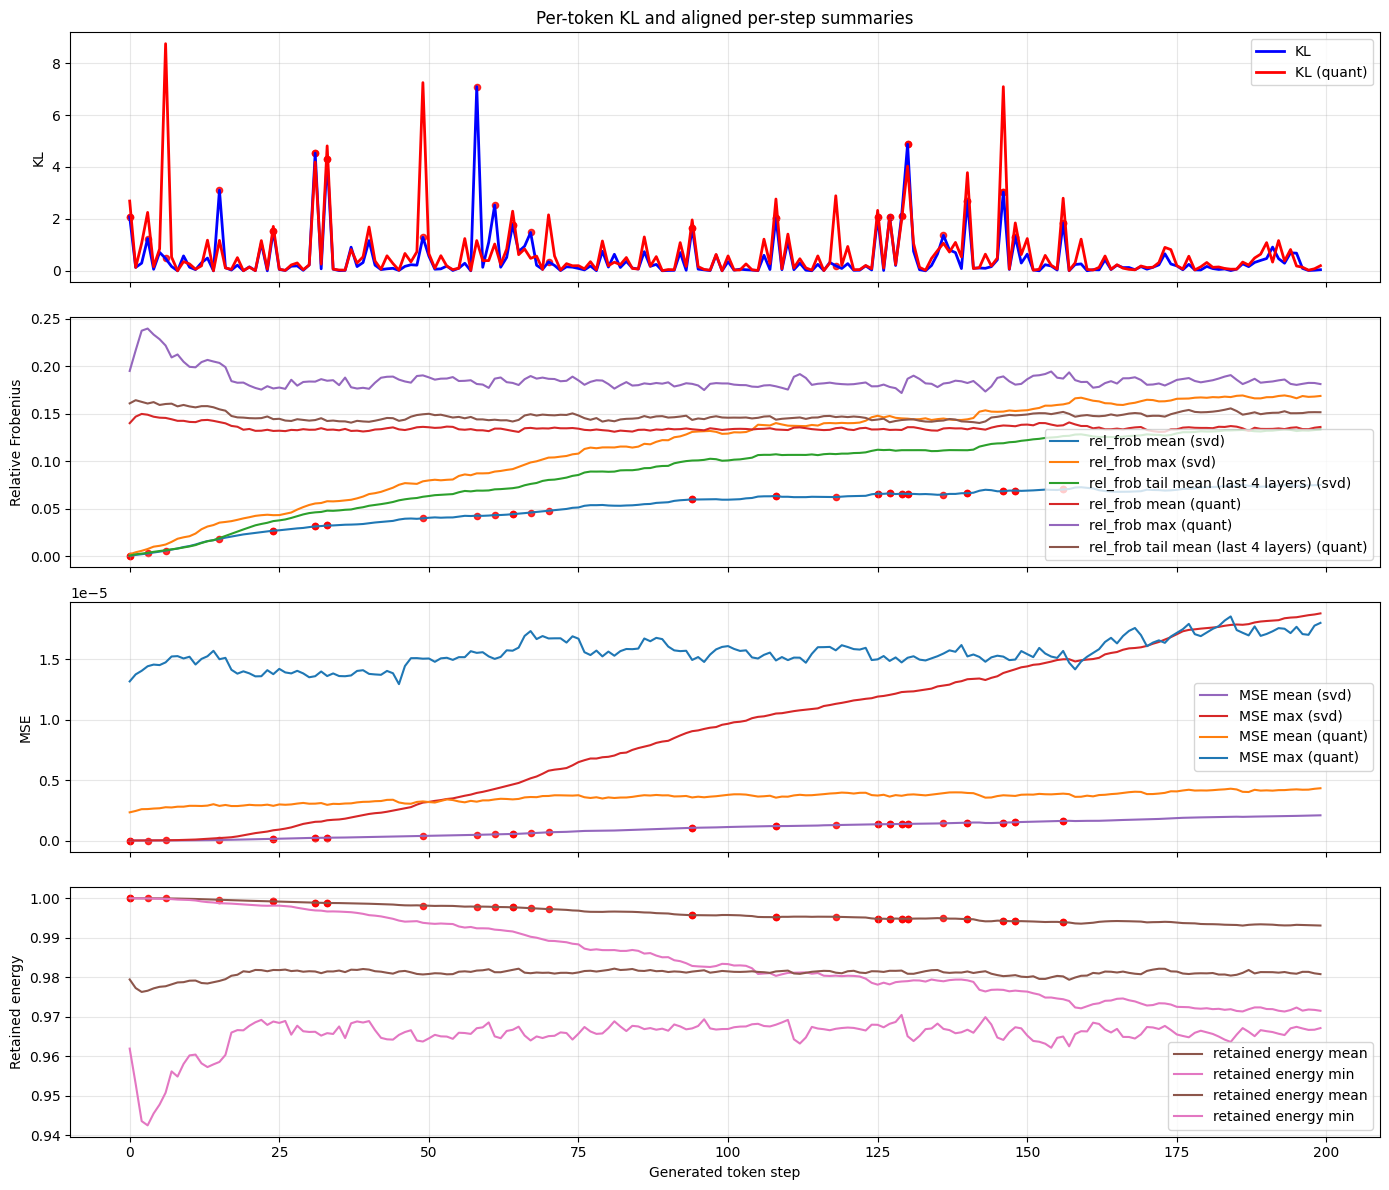

In [63]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
axes[0].plot(steps_svd, kl_svd.numpy(), label="KL", color="blue", linewidth=2)
# axes[0].plot(steps_svd, log_kl_svd.numpy(), label="log1p(KL)", color="tab:gray", linestyle="--")
axes[0].plot(steps_q, kl_q.numpy(), label="KL (quant)", color="red", linewidth=2)
# axes[0].plot(steps_q, log_kl_q.numpy(), label="log1p(KL) (quant)", color="tab:gray", linestyle="--")

axes[0].set_ylabel("KL")
axes[0].set_title("Per-token KL and aligned per-step summaries")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(steps_svd, rf_mean_svd.numpy(), label="rel_frob mean (svd)", color="tab:blue")
axes[1].plot(steps_svd, rf_max_svd.numpy(), label="rel_frob max (svd)", color="tab:orange")
axes[1].plot(steps_svd, rf_tail_svd.numpy(), label="rel_frob tail mean (last 4 layers) (svd)", color="tab:green")
axes[1].plot(steps_q, rf_mean_q.numpy(), label="rel_frob mean (quant)", color="tab:red")
axes[1].plot(steps_q, rf_max_q.numpy(), label="rel_frob max (quant)", color="tab:purple")
axes[1].plot(steps_q, rf_tail_q.numpy(), label="rel_frob tail mean (last 4 layers) (quant)", color="tab:brown")
axes[1].set_ylabel("Relative Frobenius")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[2].plot(steps_svd, mse_mean_svd.numpy(), label="MSE mean (svd)", color="tab:purple")
axes[2].plot(steps_svd, mse_max_svd.numpy(), label="MSE max (svd)", color="tab:red")
axes[2].plot(steps_q, mse_mean_q.numpy(), label="MSE mean (quant)", color="tab:orange")
axes[2].plot(steps_q, mse_max_q.numpy(), label="MSE max (quant)", color="tab:blue")
axes[2].set_ylabel("MSE")
axes[2].legend()
axes[2].grid(alpha=0.3)
axes[3].plot(steps_svd, re_mean_svd.numpy(), label="retained energy mean", color="tab:brown")
axes[3].plot(steps_svd, re_min_svd.numpy(), label="retained energy min", color="tab:pink")
axes[3].plot(steps_q, re_mean_q.numpy(), label="retained energy mean", color="tab:brown")
axes[3].plot(steps_q, re_min_q.numpy(), label="retained energy min", color="tab:pink")
axes[3].set_ylabel("Retained energy")
axes[3].set_xlabel("Generated token step")
axes[3].legend()
axes[3].grid(alpha=0.3)
for ax in axes:
    high_steps = steps_svd[high_mask_svd.numpy()]
    if len(high_steps) > 0:
        ax.scatter(high_steps, ax.get_lines()[0].get_ydata()[high_mask_svd.numpy()],
                   color="red", s=20, alpha=0.8)
    high_steps = steps_q[high_mask_q.numpy()]
    if len(high_steps) > 0:
        ax.scatter(high_steps, ax.get_lines()[0].get_ydata()[high_mask_q.numpy()],
                   color="red", s=20, alpha=0.8)
plt.tight_layout()
plt.show()

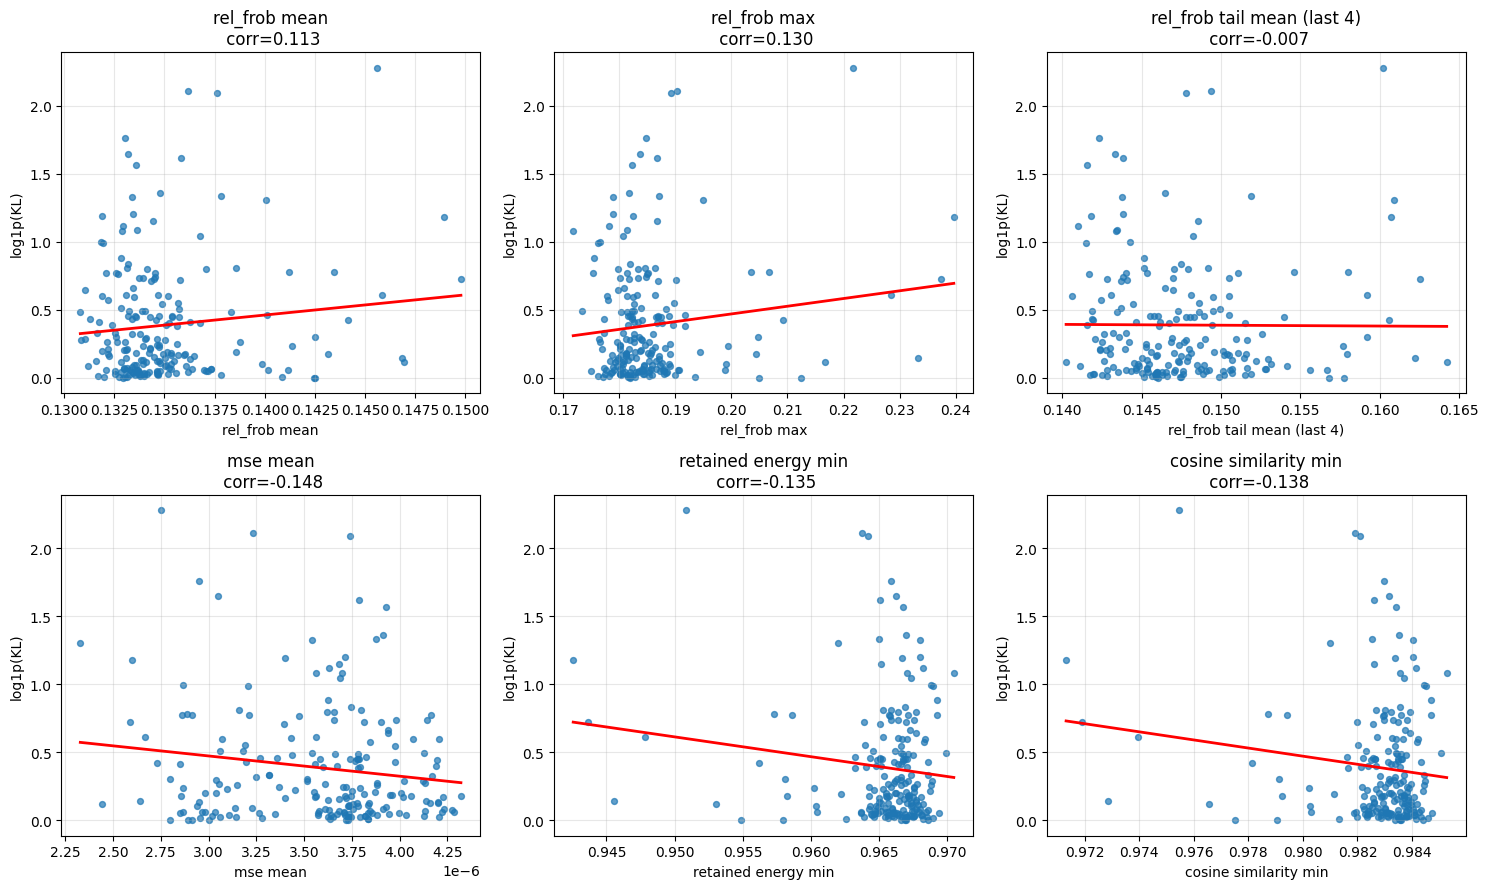

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
pairs = [
    (rf_mean, "rel_frob mean"),
    (rf_max, "rel_frob max"),
    (rf_tail, "rel_frob tail mean (last 4)"),
    (mse_mean, "mse mean"),
    (re_min, "retained energy min"),
    (cos_min, "cosine similarity min"),
]
for ax, (x, label) in zip(axes.flat, pairs):
    ax.scatter(x.numpy(), log_kl.numpy(), alpha=0.7, s=18)
    # Simple least-squares trend line
    x_np = x.numpy()
    y_np = log_kl.numpy()
    coeffs = np.polyfit(x_np, y_np, deg=1)
    x_line = np.linspace(x_np.min(), x_np.max(), 200)
    y_line = coeffs[0] * x_line + coeffs[1]
    ax.plot(x_line, y_line, color="red", linewidth=2)
    corr = np.corrcoef(x_np, y_np)[0, 1]
    ax.set_title(f"{label}\n corr={corr:.3f}")
    ax.set_xlabel(label)
    ax.set_ylabel("log1p(KL)")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

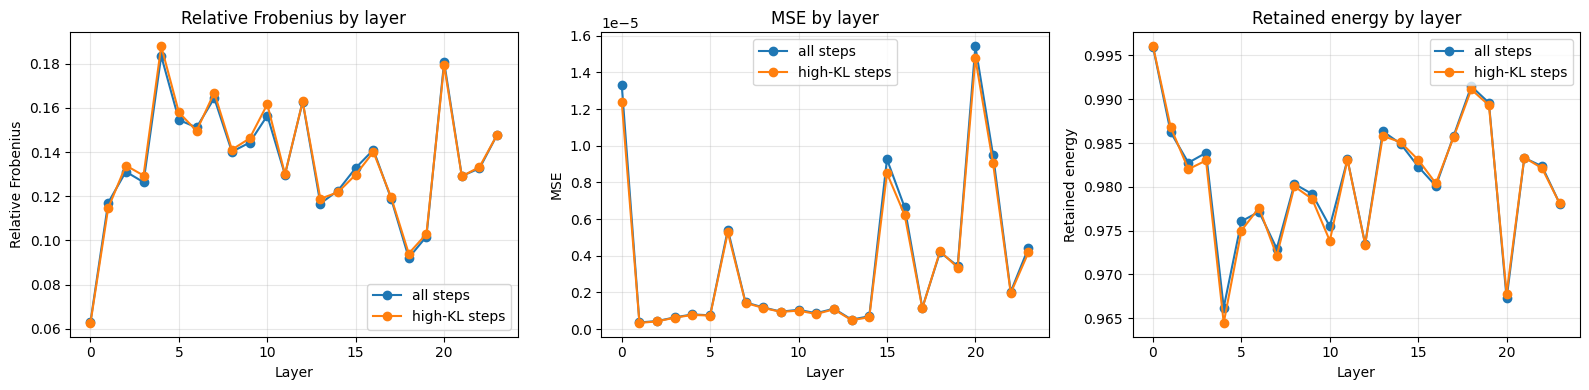

In [46]:
layers = np.arange(rf.shape[1])
rf_base = rf.mean(dim=0)
rf_high = rf[high_mask].mean(dim=0)
mse_base = mse.mean(dim=0)
mse_high = mse[high_mask].mean(dim=0)
re_base = re.mean(dim=0)
re_high = re[high_mask].mean(dim=0)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(layers, rf_base.numpy(), marker="o", label="all steps")
axes[0].plot(layers, rf_high.numpy(), marker="o", label="high-KL steps")
axes[0].set_title("Relative Frobenius by layer")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Relative Frobenius")
axes[0].grid(alpha=0.3)
axes[0].legend()
axes[1].plot(layers, mse_base.numpy(), marker="o", label="all steps")
axes[1].plot(layers, mse_high.numpy(), marker="o", label="high-KL steps")
axes[1].set_title("MSE by layer")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("MSE")
axes[1].grid(alpha=0.3)
axes[1].legend()
axes[2].plot(layers, re_base.numpy(), marker="o", label="all steps")
axes[2].plot(layers, re_high.numpy(), marker="o", label="high-KL steps")
axes[2].set_title("Retained energy by layer")
axes[2].set_xlabel("Layer")
axes[2].set_ylabel("Retained energy")
axes[2].grid(alpha=0.3)
axes[2].legend()
plt.tight_layout()
plt.show()